In [1]:
import numpy as np

from grt.planar.manifold.domain import CircularDisk
from grt.planar.manifold.metric import PoincareRMetric
from grt.planar.manifold.grid import UniformCartesianGrid
from grt.planar.influx.grid import UniformFanBeamGrid
from grt.planar.geodesics import Geodesics
from grt.planar.ray_transform import RayTransform
from grt.planar.plotting import plot_phantom, plot_reconstruction, plot_sinogram
from grt.planar.phantoms import shepp_logan
from grt.reconstruction import steepest_gradient_descent, conjugate_gradient_method

In [2]:
domain = CircularDisk(1.0)
metric = PoincareRMetric(R=1.1)

In [3]:
domain_grid = UniformCartesianGrid(domain, metric, shape=(128, 128))

In [4]:
n_alpha, n_th = 192, 256
influx_grid = UniformFanBeamGrid(n_alpha, n_th, metric, domain, domain_grid)

In [5]:
geodesics = Geodesics(metric, domain, influx_grid, step_size=0.01)

In [6]:
ray_transform = RayTransform(geodesics, domain, domain_grid, influx_grid)

In [7]:
ray_transform.matrix.shape

(49152, 12892)

In [8]:
f_c = domain_grid.coefficients_from_function(shepp_logan)
y = ray_transform.matrix @ f_c
sinogram = (1 / np.sqrt(influx_grid.cell_areas)) * y

In [9]:
sgd = steepest_gradient_descent(ray_transform.matrix, y, np.zeros(shape=f_c.shape), 0.001)

iterating...
error threashold is satisfied.


In [10]:
cgm = conjugate_gradient_method(ray_transform.matrix, y, np.zeros(shape=f_c.shape), 0.001)

iterating...
error threashold is satisfied.


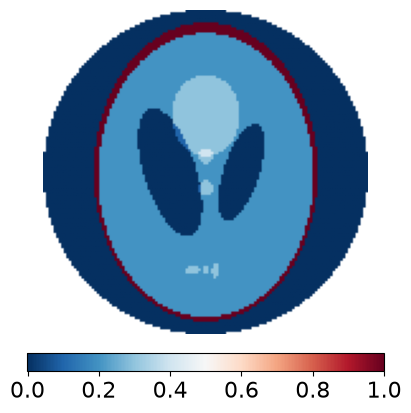

In [11]:
plot_phantom(truth=f_c, domain=domain, domain_grid=domain_grid)

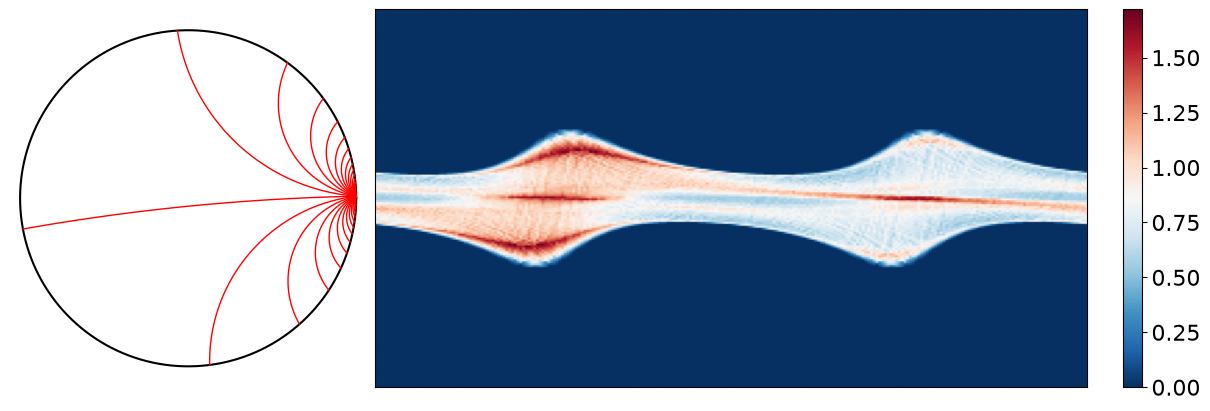

In [12]:
plot_sinogram(sinogram=sinogram, n_geodesics=30, domain=domain, influx_grid=influx_grid, geodesics=geodesics)

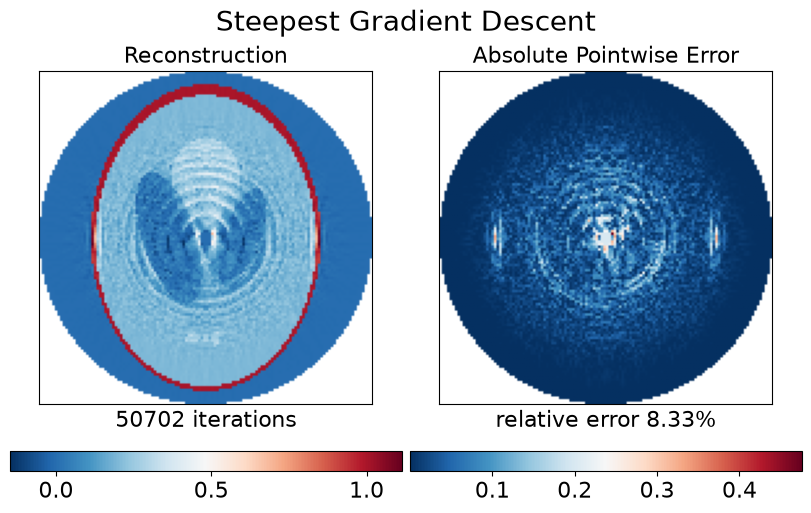

In [13]:
plot_reconstruction(truth=f_c, output=sgd, domain=domain, domain_grid=domain_grid)

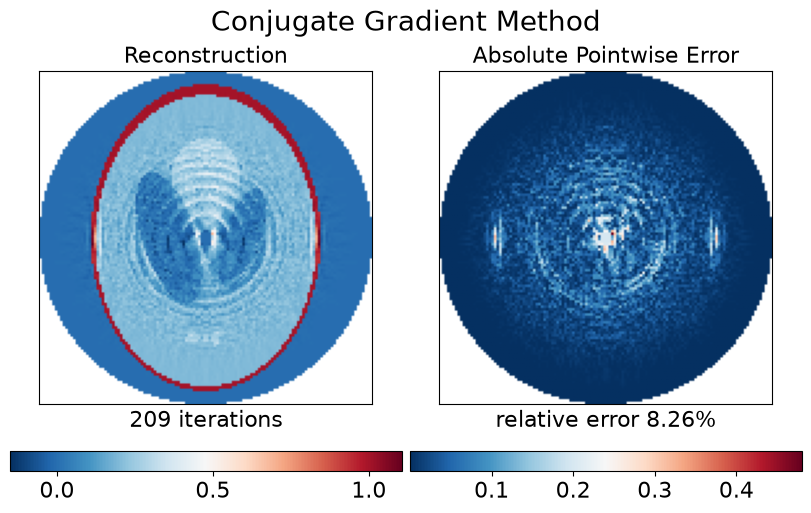

In [14]:
plot_reconstruction(truth=f_c, output=cgm, domain=domain, domain_grid=domain_grid)